In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import datetime
import joblib
import cleaning

# Load FPA FOD

In [3]:
nwcg = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Karen_email/NWCG_UnitIdActive_20200123.csv', sep = ',')

In [4]:
cols_FPA = ['DISCOVERY_DOY', 'LATITUDE', 'FIRE_YEAR', 'LONGITUDE', 'FIPS_CODE', 'Annual_etr', 'Annual_precipitation', 'NWCG_GENERAL_CAUSE',
            'Annual_tempreture', 'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 'Slope_1km',
            'TPI_1km', 'EVC', 'FRG', 'Mang_Name', 'GAP_Sts', 'GDP', 'GHM', 'NPL',
            'Popo_1km', 'RPL_THEMES']

FPA_FOD = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Data/FPA_FOD/FPA_FOD_Plus.csv',
                      sep = ',', low_memory = False)
sts = ['WA', 'OR', 'CA', 'ID', 'NV', 'MT', 'WY', 'UT', 'AZ', 'CO', 'NM']
FPA_FOD = FPA_FOD.loc[FPA_FOD['STATE'].isin(sts)]
FPA_FOD = FPA_FOD.loc[FPA_FOD['LONGITUDE'] < -102.05]

FPA_FOD = pd.merge(left = FPA_FOD,
                   left_on = 'NWCG_REPORTING_UNIT_ID',
                   right = nwcg[['UnitId', 'UnitType']],
                   right_on = 'UnitId',
                   how = 'left')

FPA_FOD = FPA_FOD[(FPA_FOD['FIRE_SIZE'] >= 0.1) & (~FPA_FOD['Land_Cover'].isin([22, 23, 24])) & (~FPA_FOD['UnitType'].isin(['US County/Local']))]
FPA_FOD = FPA_FOD[cols_FPA]

In [5]:
FPA_FOD = FPA_FOD[FPA_FOD['NWCG_GENERAL_CAUSE'] != 'Natural']

In [6]:
labels = {'USFS': 0,
        'BLM': 1,
        'UNK': 2,
        'TRIB': 3,
        'SLB': 4,
        'SFW': 5,
        'SPR': 6,
        'SDOL': 7,
        'SDNR': 8,
        'REG': 9,
        'CITY': 10,
        'NPS': 11,
        'PVT': 12,
        'NGO': 13,
        'FWS': 14,
        'CNTY': 15,
        'USBR': 16,
        'DOD': 17,
        'UNKL': 18,
        'RWD': 19,
        'USACE': 20,
        'OTHS': 21,
        'NRCS': 22,
        'ARS': 23,
        'DOE': 24,
        'JNT': 25,
        'OTHF': 26,
        'OTHR': 27,
        'SDC': 28,
        'BPA': 29}
FPA_FOD['Mang_Name'] = FPA_FOD['Mang_Name'].replace(to_replace = labels)

/tmp/ipykernel_211108/3181951399.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  FPA_FOD['Mang_Name'] = FPA_FOD['Mang_Name'].replace(to_replace = labels)


# 2019 Point dt and cleaning

In [7]:
map_dt = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Mapping/map_Dt_2019_1.csv',
                     sep = ',')
map_dt = map_dt.drop(columns = ['NWCG_GENERAL_CAUSE', 'FIRE_SIZE', 'Evacuation'])#, 'NDVI-1day'])
print(map_dt.shape)

(6159460, 43)


In [8]:
cols = ['index', 'LONGITUDE', 'LATITUDE', 'DISCOVERY_DOY', 'FIRE_YEAR',
        'FIPS_CODE', 'Annual_etr', 'Annual_precipitation', 'Annual_tempreture',
        'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km',
        'Aspect_1km', 'erc_Percentile', 'Slope_1km', 'TPI_1km', 'EVC', 'FRG',
        'Mang_Name', 'GAP_Sts', 'GDP', 'GHM', 'NPL',
        'Popo_1km', 'RPL_THEMES']
map_cln = map_dt[cols]
map_cln, cln_rslt = cleaning.cleaning(df = map_cln)
map_cln['Mang_Name'] = map_cln['Mang_Name'].replace(to_replace = labels)
map_cln[['Annual_etr', 'Annual_precipitation']] = map_cln[['Annual_etr', 'Annual_precipitation']].astype(int)
map_cln['Annual_tempreture'] = map_cln['Annual_tempreture'].round(0).astype(int)
print(map_cln.shape)

/bsuscratch/yavarpourmohamad/Dissertation/Code/Plotting_c_roadFSless/cleaning.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['erc_Percentile'] = np.mean(pd.concat(objs = [lower, upper], axis = 1), axis = 1)


(6148190, 31)


/tmp/ipykernel_211108/3364316382.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  map_cln['Mang_Name'] = map_cln['Mang_Name'].replace(to_replace = labels)


# Loading ML models

In [9]:
xgb_main = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_WW_H.pkl')
# xgb_main = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_H.pkl')

In [10]:
prob = xgb_main.predict_proba(map_cln[map_cln.columns[3:]])
prob = pd.DataFrame(data = prob, columns = ['No_fire', 'Fire'])

In [11]:
map_dt = map_cln.copy(deep = True)#[['index', 'LONGITUDE', 'LATITUDE', 'DISCOVERY_DOY']]
map_dt['Fire'] = prob['Fire'].to_numpy()
print(map_dt.shape)

(6148190, 32)


# Combine with mesh data over the index

In [12]:
grid = gpd.read_file(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Data/grid_map_2019_1.shp')
grid = grid.to_crs('EPSG:4326')
states = gpd.read_file(filename = '/bsuhome/yavarpourmohamad/scratch/FPA_FOD_Paper/Grid_variable_map/States/cb_2018_us_state_500k.shp')
states = states.loc[states['STUSPS'].isin(sts)]

In [13]:
pnt_fire = FPA_FOD[FPA_FOD['FIRE_YEAR'] == 2019]
pnt_fire = gpd.GeoDataFrame(data = pnt_fire,
                            crs = 'EPSG:4326',
                            geometry = gpd.points_from_xy(x = pnt_fire.LONGITUDE,
                                                          y = pnt_fire.LATITUDE))

In [14]:
# grid = grid.to_crs(epsg = 2163)
# states = states.to_crs(epsg = 2163)
# pnt_fire = pnt_fire.to_crs(epsg = 2163)

# Test

In [15]:
fire_days = dict()
grid_days = dict()
j = 0
for doy in [23, 248]:
    pnt_day = pnt_fire[pnt_fire['DISCOVERY_DOY'] == doy]
    temp_grd = map_dt[map_dt['DISCOVERY_DOY'] == doy]
    temp_grd = pd.merge(left = grid, right = temp_grd, left_on = 'FID', right_on = 'index', how = 'left')

    temp_grd = gpd.GeoDataFrame(data = temp_grd, geometry = 'geometry')
    rslt = gpd.sjoin(left_df = temp_grd, right_df = pnt_day, how = 'right')
    fire_days[doy] = len(rslt)
    grid_days[doy] = len(rslt[rslt['Fire'] > 0.49])

(0.0, 1.0)

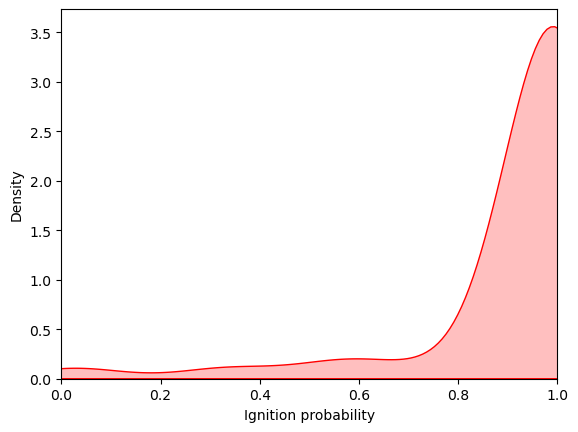

In [16]:
import seaborn as sns
sns.kdeplot(data=rslt.Fire,
            color='r',
            fill=True)
plt.xlabel('Ignition probability')
plt.xlim(0, 1)

# Test End

# Plotting

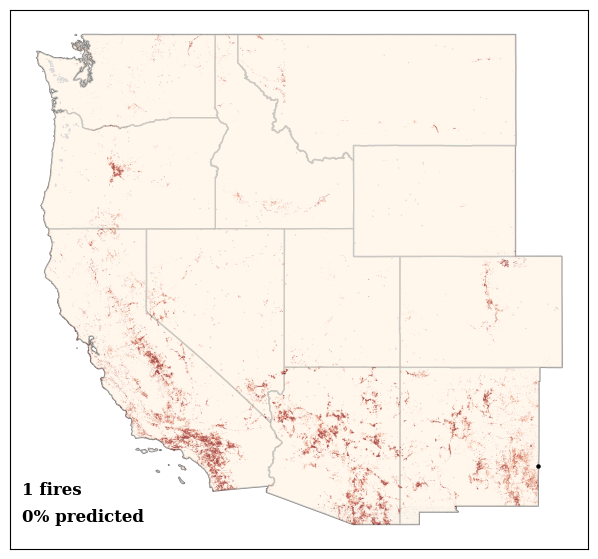

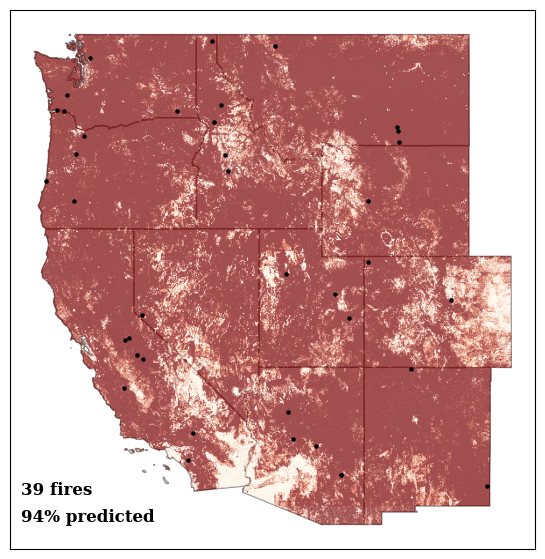

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
for doy in [23, 248]:
    temp_grd = map_dt[map_dt['DISCOVERY_DOY'] == doy]
    temp_grd = pd.merge(left = grid, right = temp_grd, left_on = 'FID', right_on = 'index', how = 'left')
    temp_pnt = pnt_fire[pnt_fire['DISCOVERY_DOY'] == doy]
    date = datetime.datetime(2019, 1, 1) + datetime.timedelta(days = doy - 1)
    fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (13, 7))
    states.plot(ax = axs, edgecolor = 'grey', color = 'white')
    temp_grd.plot(column = 'Fire',
                  cmap = 'OrRd',
                  ax = axs,
                  legend = False,
                  missing_kwds = {'color': 'lightgrey'},
                  scheme = 'equal_interval', # 'quantiles'
                  k = 4,
                  legend_kwds = {'bbox_to_anchor': (1.0, 0.53),
                                 'labels': ['Low\n(<25%)', 'Medium\n(25-50%)', 'High\n(50-75%)', 'Very High\n(>75%)'],
                                 'title' : 'Fire probability',
                                 'title_fontsize': 'xx-large', # 'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'
                                 'fancybox': True,
                                 'fontsize': 'x-large'})
    temp_pnt.plot(ax = axs, color = 'k', markersize = 5)
    axs.tick_params(axis = 'both', which = 'both', length = 0)
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    axs.text(x = 0.02,
             y = 0.1,
             s = f'{fire_days[doy]} fires',
             color = '#000000',
             fontsize = 'large',
             fontweight = 'bold', # 'ultralight', 'light', 'normal', 'regular', 'book', 'medium', 'roman', 'semibold', 'demibold', 'demi', 'bold', 'heavy', 'extra bold', 'black'
             transform = axs.transAxes)
    axs.text(x = 0.02,
             y = 0.05,
             s = f'{int(grid_days[doy]/fire_days[doy] *100)}% predicted',
             color = '#000000',
             fontsize = 'large',
             fontweight = 'bold', # 'ultralight', 'light', 'normal', 'regular', 'book', 'medium', 'roman', 'semibold', 'demibold', 'demi', 'bold', 'heavy', 'extra bold', 'black'
             transform = axs.transAxes)

    # fig.savefig(fname = f'/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Plotting_c/output/{date.strftime('%B_%d')}_H_1_C.png',
    #             dpi = 600, bbox_inches = 'tight')
    plt.show()

# Without Weight

In [17]:
# xgb_main = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_WW_H_2000.pkl')
xgb_main = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_H_2000.pkl')

In [18]:
prob = xgb_main.predict_proba(map_cln[map_cln.columns[3:]])
prob = pd.DataFrame(data = prob, columns = ['No_fire', 'Fire'])

In [19]:
map_dt = map_cln.copy(deep = True)#[['index', 'LONGITUDE', 'LATITUDE', 'DISCOVERY_DOY']]
map_dt['Fire'] = prob['Fire'].to_numpy()
print(map_dt.shape)

(6148190, 32)


In [20]:
fire_days = dict()
grid_days = dict()
j = 0
for doy in [23, 248]:
    pnt_day = pnt_fire[pnt_fire['DISCOVERY_DOY'] == doy]
    temp_grd = map_dt[map_dt['DISCOVERY_DOY'] == doy]
    temp_grd = pd.merge(left = grid, right = temp_grd, left_on = 'FID', right_on = 'index', how = 'left')

    temp_grd = gpd.GeoDataFrame(data = temp_grd, geometry = 'geometry')
    rslt = gpd.sjoin(left_df = temp_grd, right_df = pnt_day, how = 'right')
    fire_days[doy] = len(rslt)
    grid_days[doy] = len(rslt[rslt['Fire'] > 0.49])

(0.0, 1.0)

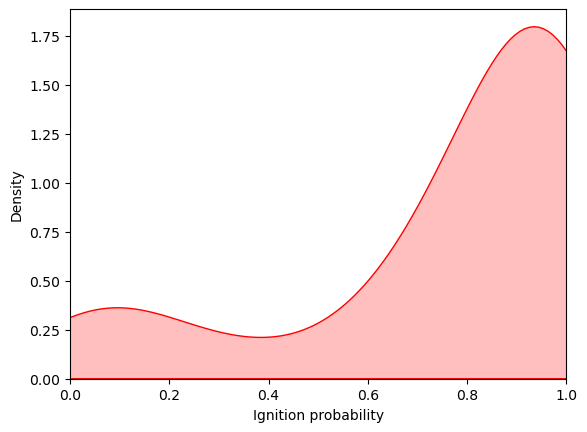

In [21]:
import seaborn as sns
sns.kdeplot(data=rslt.Fire,
            color='r',
            fill=True)
plt.xlabel('Ignition probability')
plt.xlim(0, 1)

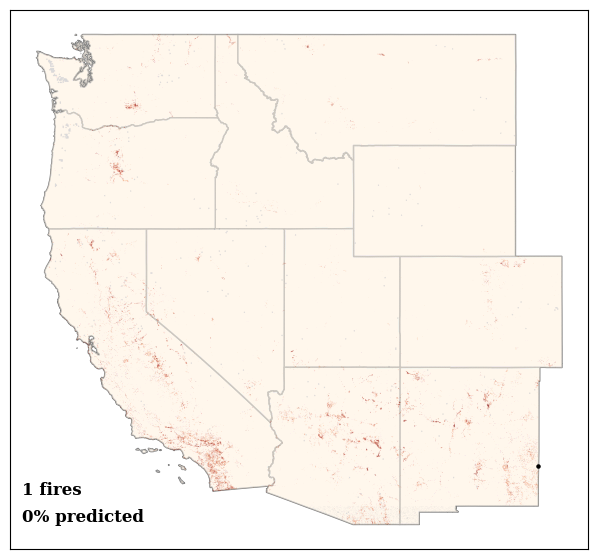

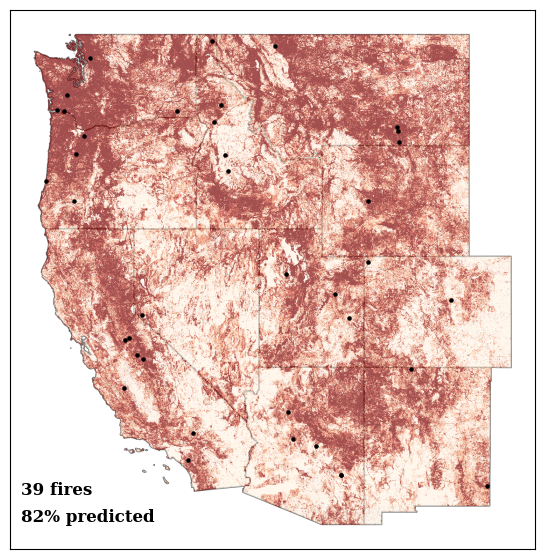

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
for doy in [23, 248]:
    temp_grd = map_dt[map_dt['DISCOVERY_DOY'] == doy]
    temp_grd = pd.merge(left = grid, right = temp_grd, left_on = 'FID', right_on = 'index', how = 'left')
    temp_pnt = pnt_fire[pnt_fire['DISCOVERY_DOY'] == doy]
    date = datetime.datetime(2019, 1, 1) + datetime.timedelta(days = doy - 1)
    fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (13, 7))
    states.plot(ax = axs, edgecolor = 'grey', color = 'white')
    temp_grd.plot(column = 'Fire',
                  cmap = 'OrRd',
                  ax = axs,
                  legend = False,
                  missing_kwds = {'color': 'lightgrey'},
                  scheme = 'equal_interval', # 'quantiles'
                  k = 4,
                  legend_kwds = {'bbox_to_anchor': (1.0, 0.53),
                                 'labels': ['Low\n(<25%)', 'Medium\n(25-50%)', 'High\n(50-75%)', 'Very High\n(>75%)'],
                                 'title' : 'Fire probability',
                                 'title_fontsize': 'xx-large', # 'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'
                                 'fancybox': True,
                                 'fontsize': 'x-large'})
    temp_pnt.plot(ax = axs, color = 'k', markersize = 5)
    axs.tick_params(axis = 'both', which = 'both', length = 0)
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    axs.text(x = 0.02,
             y = 0.1,
             s = f'{fire_days[doy]} fires',
             color = '#000000',
             fontsize = 'large',
             fontweight = 'bold', # 'ultralight', 'light', 'normal', 'regular', 'book', 'medium', 'roman', 'semibold', 'demibold', 'demi', 'bold', 'heavy', 'extra bold', 'black'
             transform = axs.transAxes)
    axs.text(x = 0.02,
             y = 0.05,
             s = f'{int(grid_days[doy]/fire_days[doy] *100)}% predicted',
             color = '#000000',
             fontsize = 'large',
             fontweight = 'bold', # 'ultralight', 'light', 'normal', 'regular', 'book', 'medium', 'roman', 'semibold', 'demibold', 'demi', 'bold', 'heavy', 'extra bold', 'black'
             transform = axs.transAxes)

    # fig.savefig(fname = f'/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Plotting_c/output/{date.strftime('%B_%d')}_all_1_C.png',
    #             dpi = 600, bbox_inches = 'tight')
    plt.show()